# Bimodal Gaussian location model

### Setup

We simulate bimodal data from a two-component Gaussian mixture, which we denote $P_0$ (see below). We define a misspecified unimodal normal-location model in PyMC and sample its predictively oriented posterior with `sample_pro`. Under misspecification, the PrO posterior predictive for $y$ should place mass near both mixture modes (Theorem 1, McLatchie et al., [arXiv:2510.01915](https://arxiv.org/abs/2510.01915)).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import xarray as xr


import pymc_prop as pro

In [2]:
az.style.use("arviz-variat")

## Simulate bimodal data

$$P_0 = 0.4\,\mathcal{N}(-1.5,\,0.7^2) + 0.6\,\mathcal{N}(2.25,\,0.7^2).$$

In [3]:
N = 800
sigma = 0.7
component_means = np.array([-1.5, 2.25])
component_weights = np.array([0.4, 0.6])
SEED = 2026

# draw component labels then observations -- reproducible rng
rng = np.random.default_rng(SEED)
components = rng.choice(len(component_means), size=N, p=component_weights)
y = rng.normal(loc=component_means[components], scale=sigma)

# plotting limits around component means
xlim = (component_means.min() - 3 * sigma, component_means.max() + 3 * sigma)

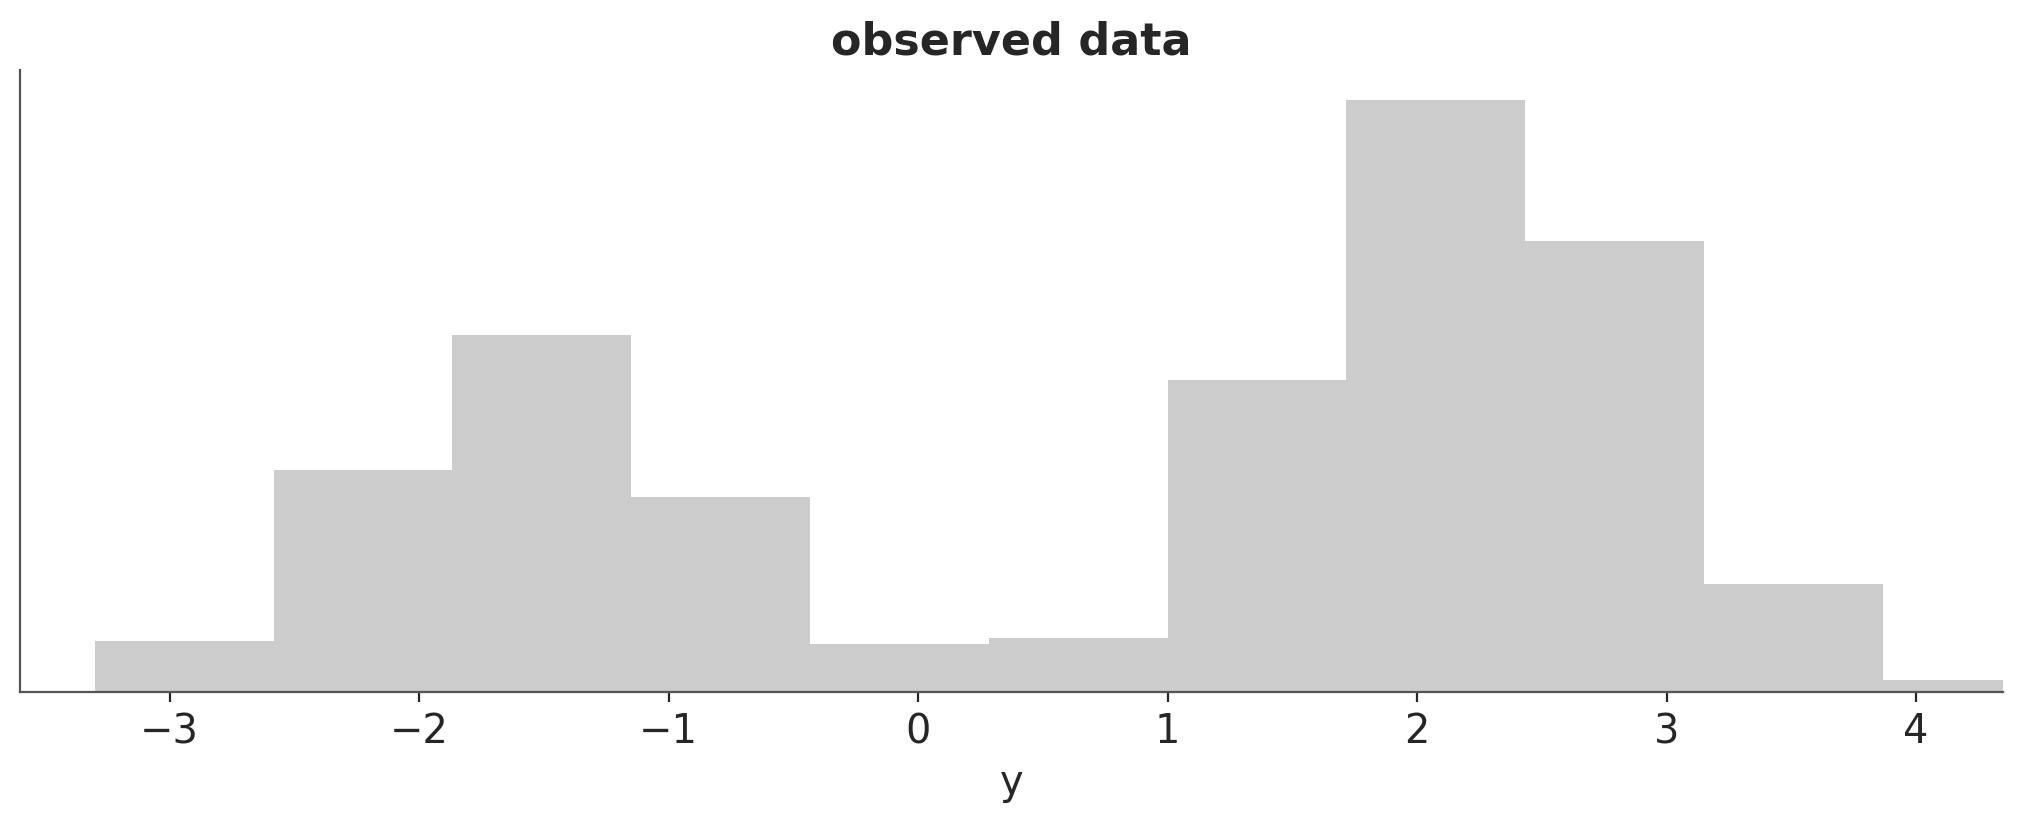

In [4]:
# histogram of the simulated data (verify bimodality)
_, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    y,
    bins="auto",
    color="0.8",
    edgecolor=None,
)
ax.set(title="observed data", xlabel="y", xlim=xlim, yticks=[]);


## PyMC model (misspecified unimodal likelihood)

We place a prior $\mathcal{N}(0, 1)$ on $\mu$ and define
$y_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$ with known $\sigma$ (same as in $P_0$).

In [5]:
# misspecified normal-location model: prior N(0,1) on mu; known sigma
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)

### Run the sampler

Sampling uses a particle-discretised Wasserstein gradient flow on $N = 800$ observations. We **retain every step** (`burn_in=0`) so we can plot full particle trajectories; the loop always runs `n_steps`, and `burn_in` only controls which steps are saved.

40 particles, 2500 steps, step size 8e-4, and learning rate $\lambda_n = 1$ (default). Below we plot particle trajectories, then a posterior predictive check in $y$-space.

In [6]:
dt = pro.sample_pro(
    model=model,
    n_particles=40,
    n_steps=2500,
    burn_in=0,
    random_seed=SEED,
)


## ArviZ DataTree output

As other inference methods in the PyMC ecosystem, `pmp.sample_pro` returns a [DataTree](https://python.arviz.org/projects/base/en/latest/tutorial/WorkingWithDataTree.html). The structure is similar to MCMC output, with `draw` and `chain` coordinates. Here `draw` is a retained index, `step` stores the simulation step number, and `chain` indexes the particle. Do not run MCMC diagnostics such as `az.rhat` or `az.ess` over particles; they are ensemble trajectories, not independent posterior draws. `sample_stats` includes heuristic `mean_log_score` and `se_log_score` traces along the flow.

In [7]:
dt

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (draw: 2500, chain: 40)
│       Coordinates:
│         * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│           step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│         * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
│       Data variables:
│           mu       (draw, chain) float64 800kB 0.01266 1.384 -2.128 ... 2.058 2.472
│       Attributes:
│           created_at:                 2026-06-10T16:12:20.178931+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 800)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
│       Data variables:
│           y        (y_dim_0) float64 6kB -1.696 2.014 2.631 ... 1.25 -0.3845 -2.138
│       Attributes:
│           created_at:                 2026-06-10T16:12:20.181070+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /log_likelihood
│       Dimensions:  (draw: 2500, chain: 40, y_dim_0: 800)
│       Coordinates:
│         * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│           step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│         * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
│         * y_dim_0  (y_dim_0) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
│       Data variables:
│           y        (draw, chain, y_dim_0) float64 640MB -3.542 -4.648 ... -22.25
│       Attributes:
│           created_at:                 2026-06-10T16:12:20.178931+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
└── Group: /sample_stats
        Dimensions:          (draw: 2500, chain: 40)
        Coordinates:
          * draw             (draw) int64 20kB 0 1 2 3 4 5 ... 2495 2496 2497 2498 2499
            step             (draw) int64 20kB 0 1 2 3 4 5 ... 2495 2496 2497 2498 2499
          * chain            (chain) int64 320B 0 1 2 3 4 5 6 7 ... 33 34 35 36 37 38 39
        Data variables:
            particle_spread  (draw, chain) float64 800kB 2.02 2.02 2.02 ... 1.838 1.838
            learning_rate    (draw, chain) float64 800kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
            mu_spread        (draw, chain) float64 800kB 2.02 2.02 2.02 ... 1.838 1.838
            mean_log_score   (draw, chain) float64 800kB -6.946e+03 ... -6.256e+03
            se_log_score     (draw, chain) float64 800kB 540.7 540.7 ... 253.0 253.0
        Attributes:
            created_at:                 2026-06-10T16:12:20.178931+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            sample_dims:                ['draw', 'chain']
            inference_library:          pymc
            inference_library_version:  6.0.0

## Particle trajectories

Each line is one particle $\mu_t^{(j)}$. Under misspecification, trajectories often split across both true component means.

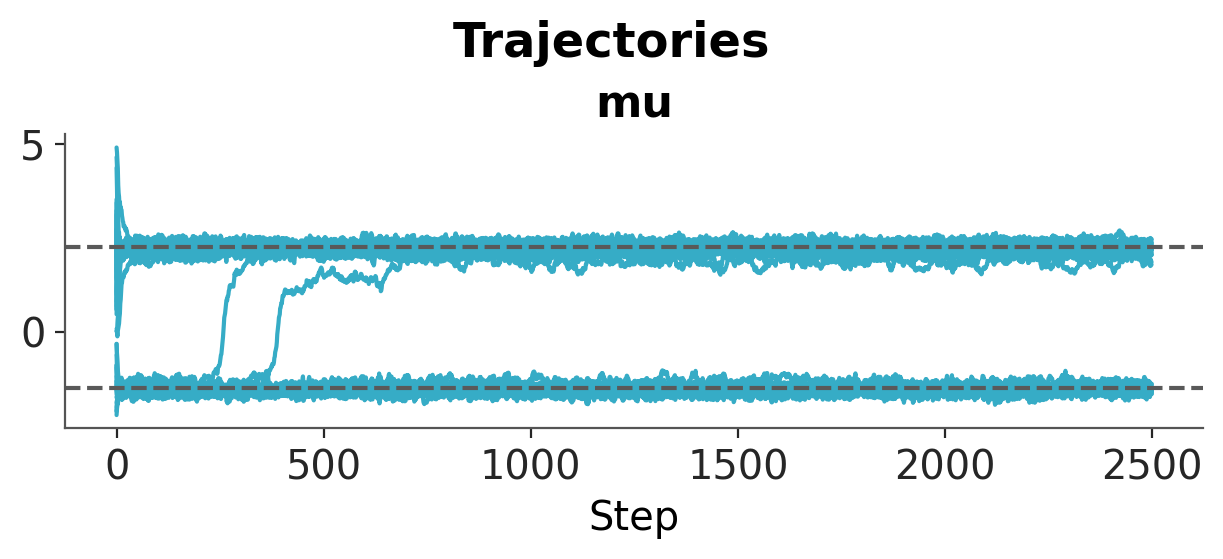

In [8]:
pc = az.plot_trace(
    dt,
    var_names=["mu"],
    aes={"color": False, "overlay": ["chain"]},
    visuals={"trace": {"color": "C0", "xname": "step"}},
)
pc = az.add_lines(
    pc,
    values=list(component_means),
    orientation="horizontal",
)

pc.add_title("Trajectories")

We are going to remove the first 100 steps. In future iterations of the sampler, the tuning phase will, hopefully, automatically discard early steps where trajectories are still converging to the flow.

In [9]:
dt_bi = dt.filter(lambda node: "draw" in node.dims).sel(draw=slice(100, None, 10))

In [ ]:
# We should handle this on our side so we can return the `posterior_predictive` group directly
# Usually in pymc this is done with pm.sample_posterior_predictive
# But given that the focus of the PrO posterior is the posterior predictive 
# we may want to return also the `posterior_predictive` group directly from `sample_pro`???

num_samples = 50
N = dt.observed_data["y"].size
rng = np.random.default_rng(221)

indices = rng.choice(dt_bi.posterior["mu"].draw, size=num_samples, replace=False)
posterior = dt_bi.posterior["mu"].sel(draw=indices)

chain_indices = rng.integers(0, posterior.sizes["chain"], size=(num_samples, 800))
mu_expanded = np.take_along_axis(posterior.values, chain_indices, axis=1)

y_pp_data = rng.normal(loc=mu_expanded, scale=sigma)

y_pp = xr.Dataset({"y": (["draws", "y_dim_0"], y_pp_data)})
dt["posterior_predictive"] = y_pp

something, soemthing... we match the observations

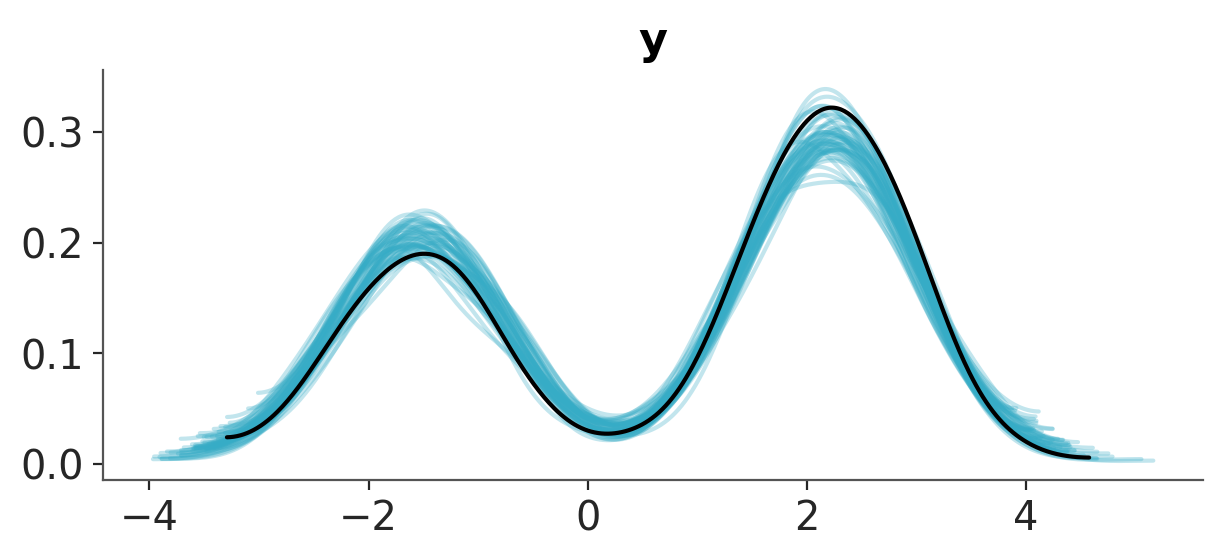

In [11]:
pc = az.plot_ppc_dist(dt, sample_dims=["draws"])